# Plot: organoid- vs. single-cell-level term importance

Loads the organoid-vs-single-cell comparison table from `1.variate_importance.ipynb` (`results/variate_importance/term_importance_organoid_vs_sc.parquet`) and plots the two profile levels side by side.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/variate_importance")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/variate_importance")

compare = pd.read_parquet(
    results_path / "term_importance_organoid_vs_sc.parquet"
).set_index("term")
print(compare)

                          organoid  single_cell  \
term                                              
treatment                 0.244693     0.212680   
patient                   7.438156     7.372769   
treatment:patient         1.474915     1.407939   
cell_count                2.904882     0.401922   
organoid_count            0.412664     0.286606   
cell_per_organoid_count   0.098527     0.267272   
residual                 87.475101    90.093347   

                         difference (organoid - single_cell)  
term                                                          
treatment                                           0.032013  
patient                                             0.065387  
treatment:patient                                   0.066976  
cell_count                                          2.502960  
organoid_count                                      0.126058  
cell_per_organoid_count                            -0.168745  
residual                            

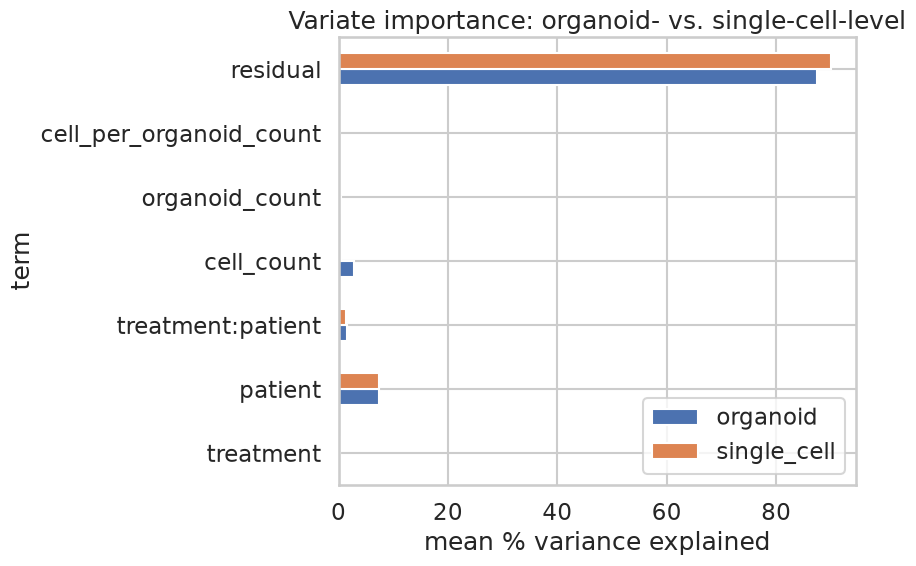

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))
compare[["organoid", "single_cell"]].plot(kind="barh", ax=ax)
ax.set_xlabel("mean % variance explained")
ax.set_title("Variate importance: organoid- vs. single-cell-level")
plt.tight_layout()
plt.savefig(
    figures_path / "organoid_vs_sc_term_importance.png", dpi=600, bbox_inches="tight"
)
plt.show()